**COMANDO WSL2 — EXECUTAR FASE COMPLETA**

```bash
make fase2
```

**TÍTULO**

F2Z — Sanidade das variáveis semanais contratadas

**Projeto:** NINO-BRASIL — Oceanografia Física — UFPE  
**Código canônico:** `F2Z`  
**Objeto de estudo:** processo físico definido para esta etapa do projeto  
**Família de hipótese:** `HIP0`

**CONTEXTO**

A Fase 2 recebe fontes atualizadas pela Fase 1, trata e organiza uma matriz semanal comum e disponibiliza os produtos. O notebook documenta cobertura real, data máxima válida, defasagem por fonte, unidades, calendários, lacunas, transformações, gráficos de sanidade e validações independentes.

**PERGUNTA CIENTÍFICA**

Todas as variáveis físicas contratadas possuem cobertura, unidade e continuidade adequadas?

**MOTIVAÇÃO**

*Hipótese específica*

A matriz semanal contém cobertura e continuidade suficientes para comparar eventos ENSO sem que lacunas, unidades incompatíveis ou mudanças de fonte expliquem artificialmente os padrões atribuídos ao ciclo.

A hipótese poderá ser sustentada, parcialmente sustentada ou rejeitada; a execução do notebook não antecipa o resultado.

*Função dos testes e unidade de análise*

A auditoria é descritiva e contratual porque qualidade de entrada não deve ser inferida pelo desempenho posterior. Cobertura por variável, intervalos temporais, unidades, valores ausentes e descontinuidades são avaliados explicitamente e registrados antes da Fase 3.

**METODOLOGIA**

Auditoria de cobertura, distribuição, continuidade temporal e contratos de unidade antes de qualquer inferência.

**RESULTADOS ESPERADOS**

Resultados esperados significam produtos necessários para responder à pergunta, não valores ou significâncias presumidos:

- inventário completo das variáveis contratadas com fonte, unidade e cobertura temporal.
- diagnóstico de lacunas, duplicidades, descontinuidades e faixas implausíveis.
- frescor real por variável, sem confundir extensão do eixo com dado válido.
- validação CTD/WOD de UFS+GLORYS e auditoria das malhas IBGE quando disponível.
- comparação explícita de frequência, cobertura, variáveis diretas e variáveis calculadas de UFS+GLORYS e ORAS5.

- figuras públicas iniciadas por `FigF2Z`;
- tabelas públicas iniciadas por `TabF2Z`;
- primeiro par reservado: `FigF2Z1` ↔ `TabF2Z1`;
- toda interpretação deve apontar para tabela, run_id, unidade, amostra e limitações.

*Fundamentação científica mínima*

As referências completas utilizadas estão na última célula do notebook.

**PREMISSAS DE VALIDADE E LIMITES DE INTERPRETAÇÃO**

- Toda conclusão deve nascer de uma tabela `Tab...` persistida antes da figura correspondente.
- A execução é determinística e usa somente entradas declaradas no inventário mostrado abaixo.
- Notebook executado não implica hipótese confirmada; gates científicos são exibidos como resultados.

In [1]:
from pathlib import Path
import os
import sys
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
NOTEBOOK_CODE = 'F2Z'
MODE = os.environ.get('NINO26_NOTEBOOK_MODE', 'official')
RUN_PIPELINE = os.environ.get('NINO26_RUN_PIPELINE', '0') == '1'
if RUN_PIPELINE:
    raise RuntimeError('O núcleo numérico deve ser executado pelo runner da fase, antes do notebook.')
from nino_brasil.notebook_workflows import NotebookWorkflow
workflow = NotebookWorkflow(ROOT, NOTEBOOK_CODE, mode=MODE)
workflow.describe()

{
  "notebook_code": "F2Z",
  "phase": 2,
  "enso_type": null,
  "mode": "official",
  "execution_policy": "numeric-core-first-viewer-publisher"
}


{'notebook_code': 'F2Z',
 'phase': 2,
 'enso_type': None,
 'mode': 'official',
 'execution_policy': 'numeric-core-first-viewer-publisher'}

**DADOS**

In [2]:
input_inventory = workflow.input_inventory()
display(input_inventory)
workflow.require_inputs()

,role,path,required,exists,bytes
0,master F2,data\processed\parquet\features\nino34_master_...,True,True,1421907
1,contrato dinâmico das variáveis semanais,data\processed\parquet\statistics\phase2_varia...,True,True,2886
2,auditoria de cobertura F2,data\processed\parquet\statistics\phase2_maste...,True,True,2051
3,validação estrutural F2,data\processed\parquet\statistics\phase2_maste...,True,True,1750
4,frescor e cobertura por variável,data\processed\parquet\statistics\phase2_maste...,True,True,2020
5,validação CTD/WOD,data\processed\parquet\statistics\phase2_ctd_v...,True,True,1442
6,auditoria IBGE da F1,data\processed\parquet\statistics\phase1_ibge_...,False,True,738
7,frequencia e variaveis das fontes oceanicas,data\processed\parquet\statistics\phase2_ocean...,True,True,1548


**RESULTADOS**

In [3]:
result = workflow.run()
display(result.artifacts)
display(result.summary)

,notebook_code,ordinal,namespace,figure_code,table_code,figure_path,table_path,manifest_path,figure_sha256,table_sha256,run_id
0,F2Z,1,fase2,FigF2Z1_contrato_disponibilidade,TabF2Z1_contrato_disponibilidade,C:\DEV\NINO26\data\processed\figures\fase2\Fig...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\metadata\figure-t...,dae46ccd6430e9ebd32781cc10b63d679d27f68793d994...,7d4a19eb6e1fbe76f0cb872742419e439c8229964e5062...,phase2_20260715T205936Z_64adc71c
1,F2Z,2,fase2,FigF2Z2_status_atualizacao_base_completa,TabF2Z2_status_atualizacao_base_completa,C:\DEV\NINO26\data\processed\figures\fase2\Fig...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\metadata\figure-t...,e601438b221f3ee7b8133303bbf27f3bb517c43b777d3d...,17e1f15470a8762c16664d53b7d791f17b0f9e2749d45b...,phase2_20260715T205936Z_64adc71c
2,F2Z,3,fase2,FigF2Z3_series_oceanograficas,TabF2Z3_series_oceanograficas,C:\DEV\NINO26\data\processed\figures\fase2\Fig...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\metadata\figure-t...,57d787d2f941880f45f41a8202ee3d14d91594b81645af...,91039f33bb609f56cea55b9a64a2af3e34aed6beb49f79...,phase2_20260715T205936Z_64adc71c
3,F2Z,4,fase2,FigF2Z4_series_atmosfericas,TabF2Z4_series_atmosfericas,C:\DEV\NINO26\data\processed\figures\fase2\Fig...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\metadata\figure-t...,f9e1cd649816fe84328ff050f49b25487fa7260e330a37...,83032cbac5935525c6cb9eec48b35b14650ce6e7cda9ff...,phase2_20260715T205936Z_64adc71c
4,F2Z,5,fase2,FigF2Z5_serie_anomalia_nino34,TabF2Z5_serie_anomalia_nino34,C:\DEV\NINO26\data\processed\figures\fase2\Fig...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\metadata\figure-t...,32ca47af24208b4d27d056041d36306039d78f3aef4266...,158450b47c33abca121e05352863ec480cd4eae0e4bfcd...,phase2_20260715T205936Z_64adc71c
5,F2Z,6,fase2,FigF2Z6_frescor_fontes,TabF2Z6_frescor_fontes,C:\DEV\NINO26\data\processed\figures\fase2\Fig...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\metadata\figure-t...,3c4ab516f0a193cc98473a88908942cfc4e0dfe74b0766...,fbdc65d1d5e6203afdff39b9ab7e3924bef810f28a026b...,phase2_20260715T205936Z_64adc71c
6,F2Z,7,fase2,FigF2Z7_validacao_ctd_wod,TabF2Z7_validacao_ctd_wod,C:\DEV\NINO26\data\processed\figures\fase2\Fig...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\metadata\figure-t...,4ca78115d9243929732abdb5bff9335f6c0321228f9cf4...,142facc4491b81b6127c27b1a2e96ab5705df23ffe5103...,phase2_20260715T205936Z_64adc71c
7,F2Z,8,fase2,FigF2Z8_fontes_oceanicas_frequencia_variaveis,TabF2Z8_fontes_oceanicas_frequencia_variaveis,C:\DEV\NINO26\data\processed\figures\fase2\Fig...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\metadata\figure-t...,e3d93727dff523453e5ca1a6471a3710dbbe55fb5ad63b...,c8d0b31c064713e19ea7caf9d82c33402d9fca51c97373...,phase2_20260715T205936Z_64adc71c
8,F2Z,9,fase2,FigF2Z9_auditoria_ibge,TabF2Z9_auditoria_ibge,C:\DEV\NINO26\data\processed\figures\fase2\Fig...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\metadata\figure-t...,6491e0a7cf494fcd5739412f4dd04e7f16caff6b30c1aa...,43c8c08f880c3efb1c8ab60a1edc787eda1e24b23dfca1...,phase2_20260715T205936Z_64adc71c


,variavel,familia,fonte,unidade,intervalo_entrada,intervalo_analise,tratamento_ate_master,representacao_no_master,inicio_disponivel,fim_disponivel,semanas_validas,semanas_grade,cobertura_percentual,maior_lacuna_semanas,apta_sem_tratamento_extra,escopo_da_aprovacao,alerta_modelagem,mensal_disponivel_na_f2
0,nino34_ssta,anomalia oceânica (Niño-3.4),NOAA OISST,degC,diário,semanal (W-SUN),Séries físicas diárias; depois média semanal W...,unchanged_independent_anomaly,1981-09-06,2026-06-14,2337,2376,98.359,0,True,estatística descritiva/associativa semanal; us...,"em CV preditiva, preservar a separação tempora...",False
1,d20_m,oceanográficas,UFS/GLORYS/GLO12,m,diário,semanal (W-SUN),Séries físicas diárias; depois média semanal W...,source_seasonal_anomaly_detrended,1981-09-06,2026-06-14,2337,2376,98.359,0,True,estatística descritiva/associativa semanal; us...,"em CV preditiva, refazer climatologia/ajuste n...",False
2,tilt_m,oceanográficas,UFS/GLORYS/GLO12,m,diário,semanal (W-SUN),Séries físicas diárias; depois média semanal W...,source_seasonal_anomaly_detrended,1981-09-06,2026-06-14,2337,2376,98.359,0,True,estatística descritiva/associativa semanal; us...,"em CV preditiva, refazer climatologia/ajuste n...",False
3,tilt_slope,oceanográficas,UFS/GLORYS/GLO12,m degree-1,diário,semanal (W-SUN),Séries físicas diárias; depois média semanal W...,source_seasonal_anomaly_detrended,1981-09-06,2026-06-14,2337,2376,98.359,0,True,estatística descritiva/associativa semanal; us...,"em CV preditiva, refazer climatologia/ajuste n...",False
4,ohc_0_100,oceanográficas,UFS/GLORYS/GLO12,J m-2,diário,semanal (W-SUN),Séries físicas diárias; depois média semanal W...,source_seasonal_anomaly_detrended,1981-09-06,2026-06-14,2337,2376,98.359,0,True,estatística descritiva/associativa semanal; us...,"em CV preditiva, refazer climatologia/ajuste n...",False
5,ohc_0_300,oceanográficas,UFS/GLORYS/GLO12,J m-2,diário,semanal (W-SUN),Séries físicas diárias; depois média semanal W...,source_seasonal_anomaly_detrended,1981-09-06,2026-06-14,2337,2376,98.359,0,True,estatística descritiva/associativa semanal; us...,"em CV preditiva, refazer climatologia/ajuste n...",False
6,ohc_0_700,oceanográficas,UFS/GLORYS/GLO12,J m-2,diário,semanal (W-SUN),Séries físicas diárias; depois média semanal W...,source_seasonal_anomaly_detrended,1981-09-06,2026-06-14,2337,2376,98.359,0,True,estatística descritiva/associativa semanal; us...,"em CV preditiva, refazer climatologia/ajuste n...",False
7,ohc_300_700,oceanográficas,UFS/GLORYS/GLO12,J m-2,diário,semanal (W-SUN),Séries físicas diárias; depois média semanal W...,source_seasonal_anomaly_detrended,1981-09-06,2026-06-14,2337,2376,98.359,0,True,estatística descritiva/associativa semanal; us...,"em CV preditiva, refazer climatologia/ajuste n...",False
8,ssh_m,oceanográficas,UFS/GLORYS/GLO12,m,diário,semanal (W-SUN),Séries físicas diárias; depois média semanal W...,source_seasonal_anomaly_detrended,1981-09-06,2026-06-14,2337,2376,98.359,0,True,estatística descritiva/associativa semanal; us...,"em CV preditiva, refazer climatologia/ajuste n...",False
9,wwv,oceanográficas,UFS/GLORYS/GLO12,m3,diário,semanal (W-SUN),Séries físicas diárias; depois média semanal W...,source_seasonal_anomaly_detrended,1981-09-06,2026-06-14,2337,2376,98.359,0,True,estatística descritiva/associativa semanal; us...,"em CV preditiva, refazer climatologia/ajuste n...",False


**FIGURAS PARA VERIFICAÇÃO RÁPIDA**

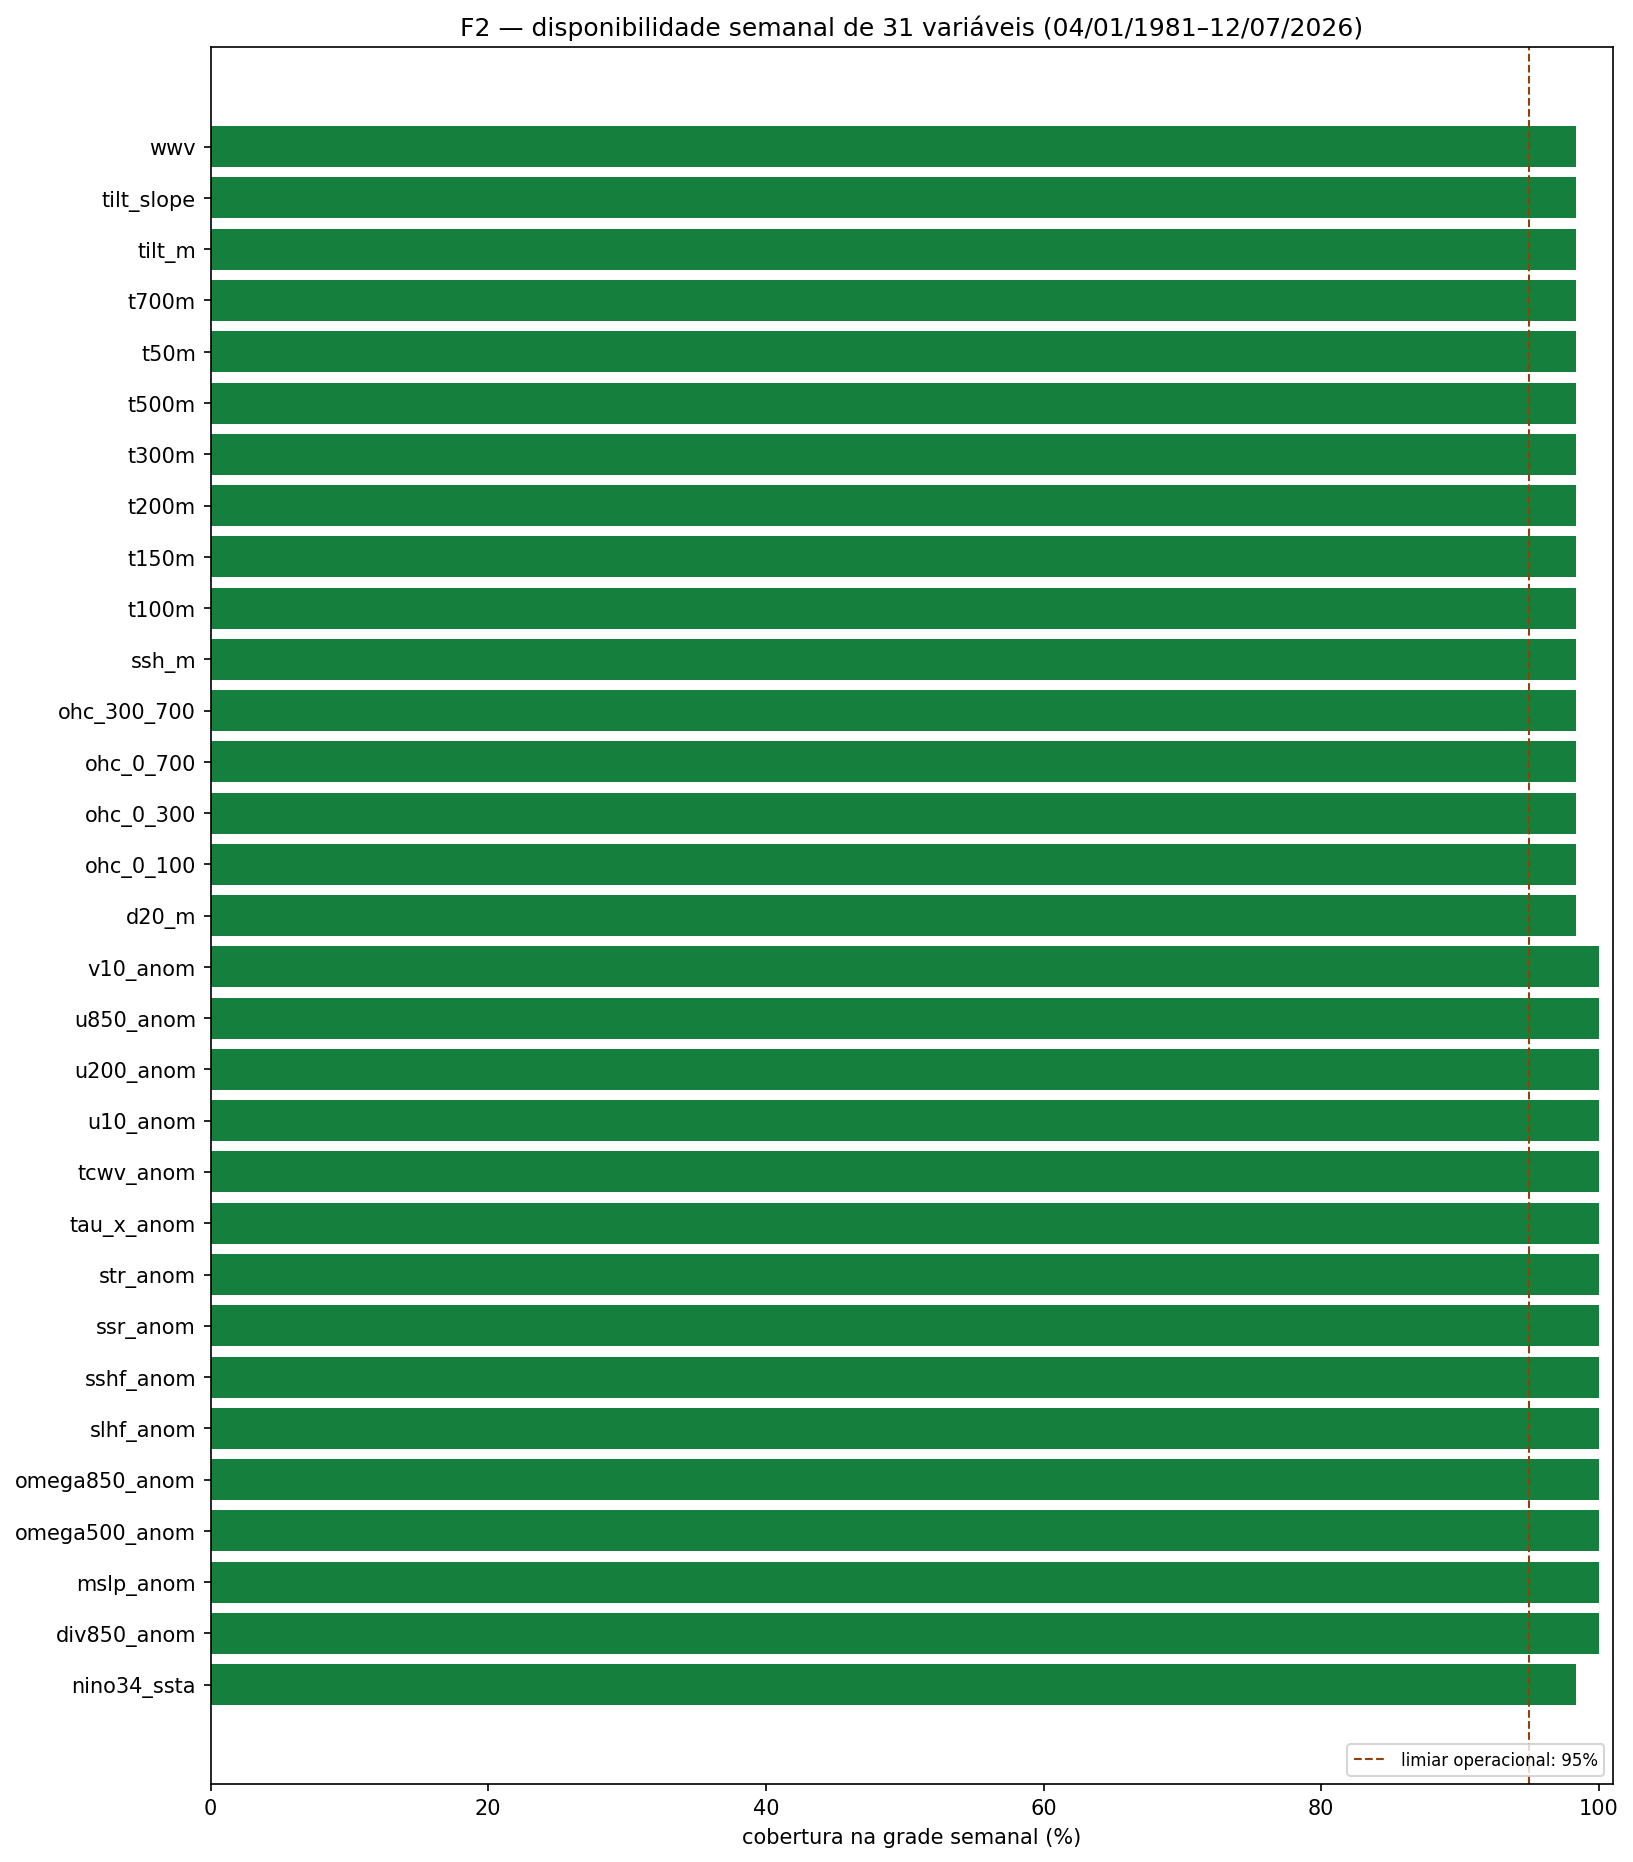

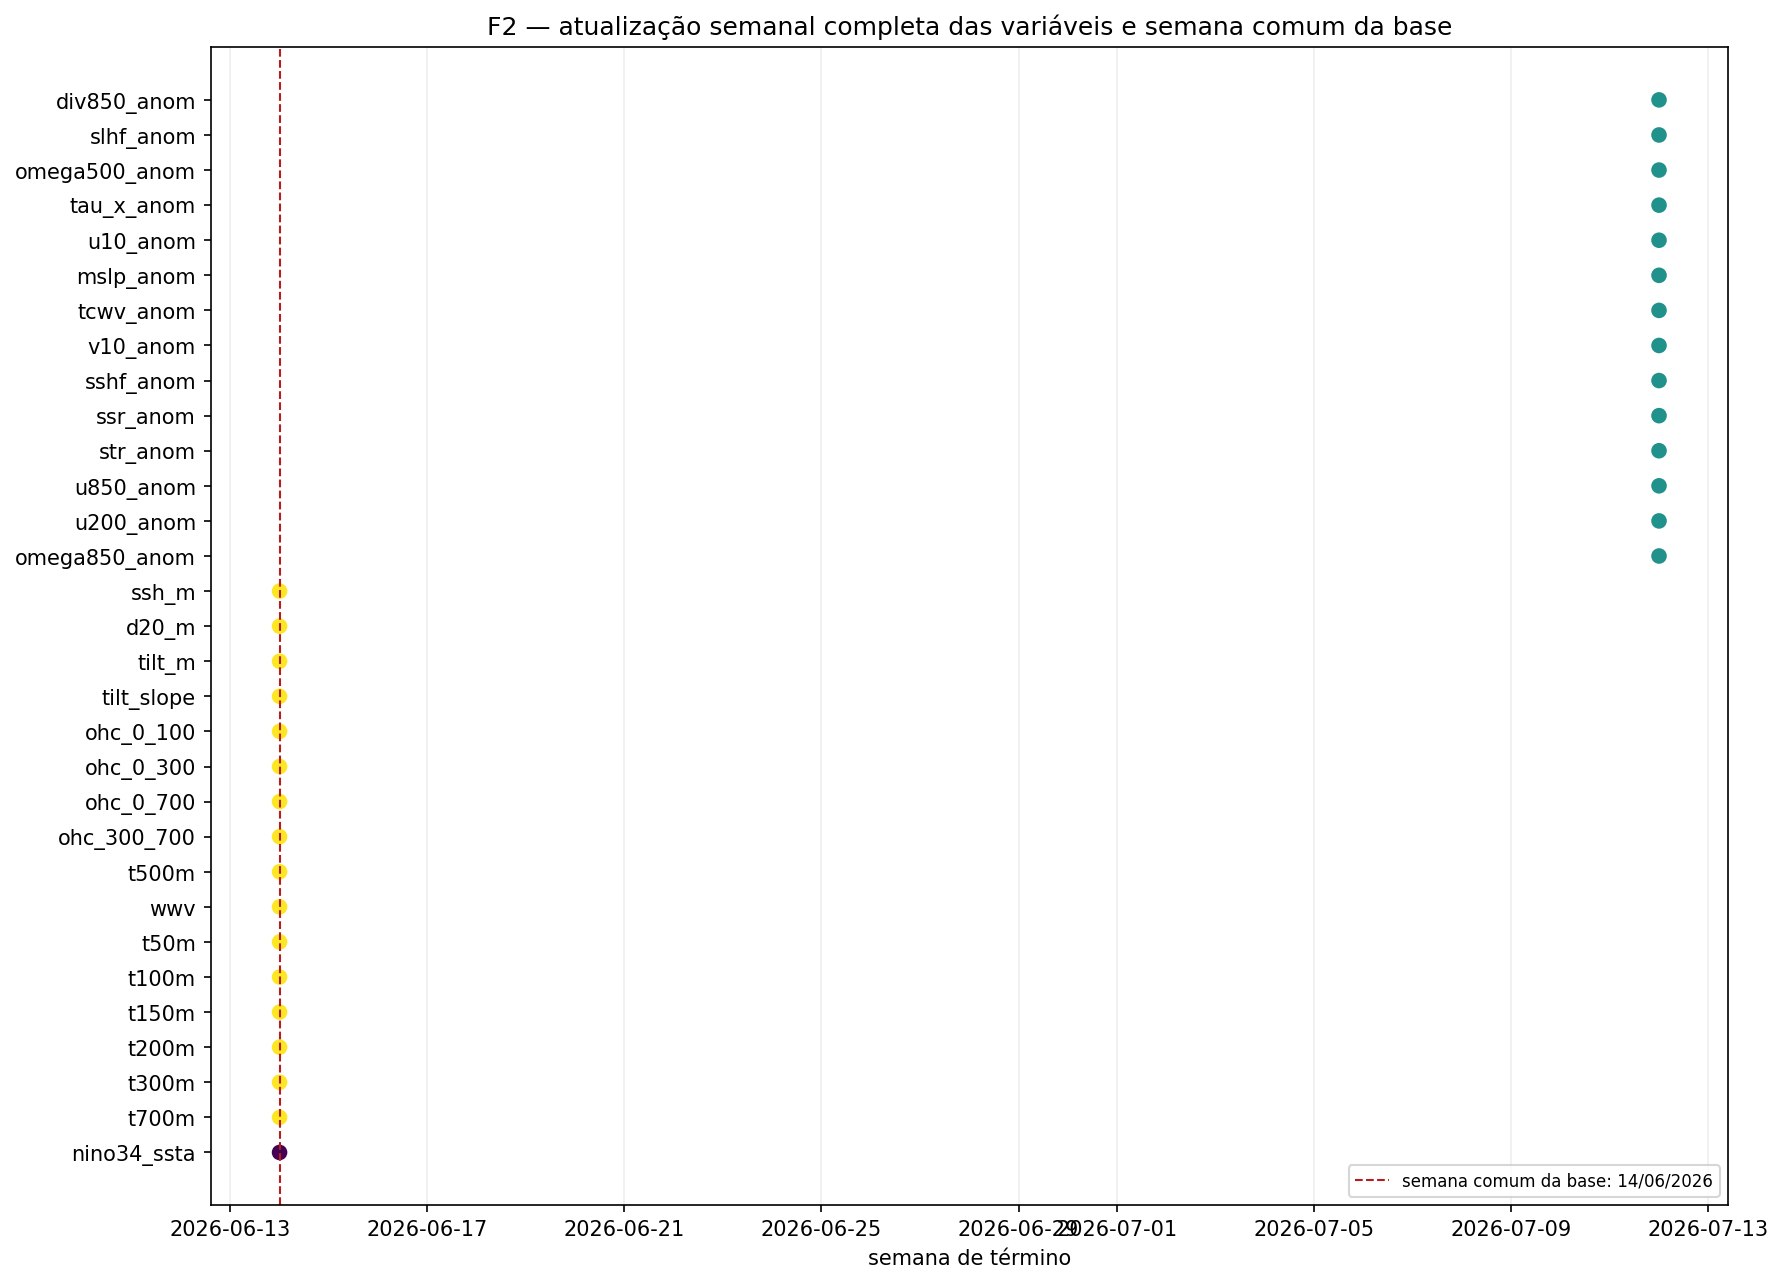

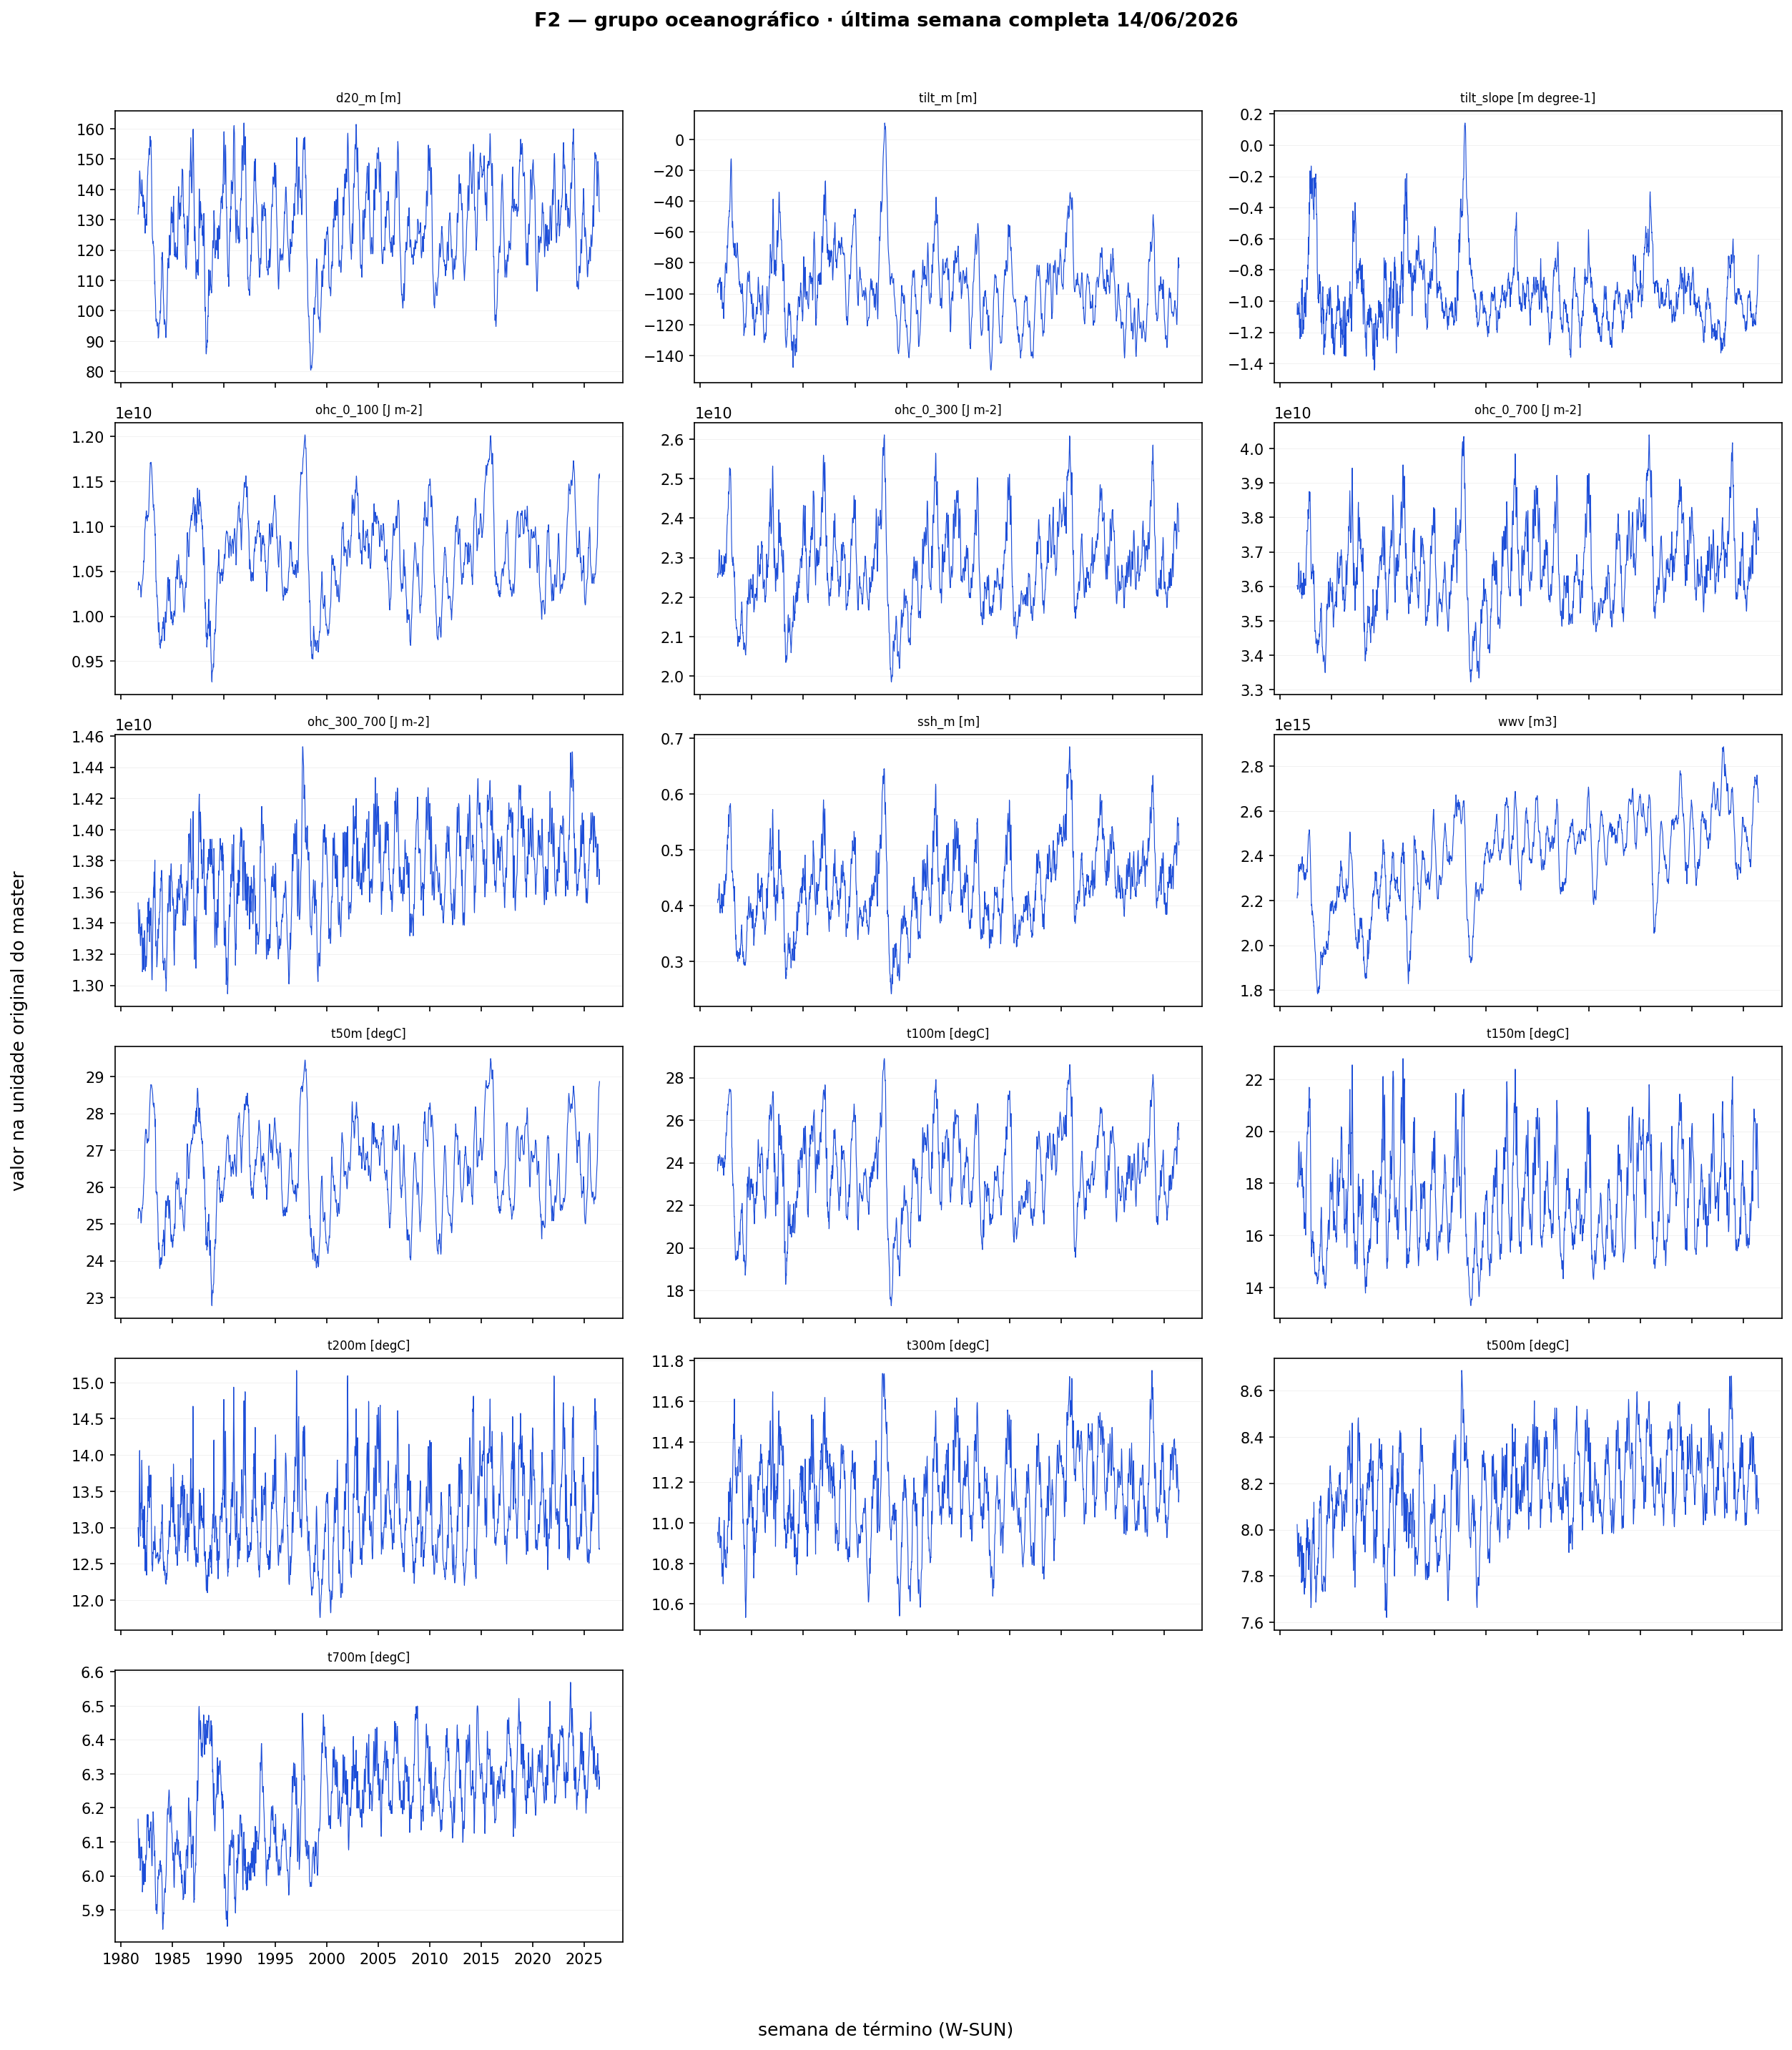

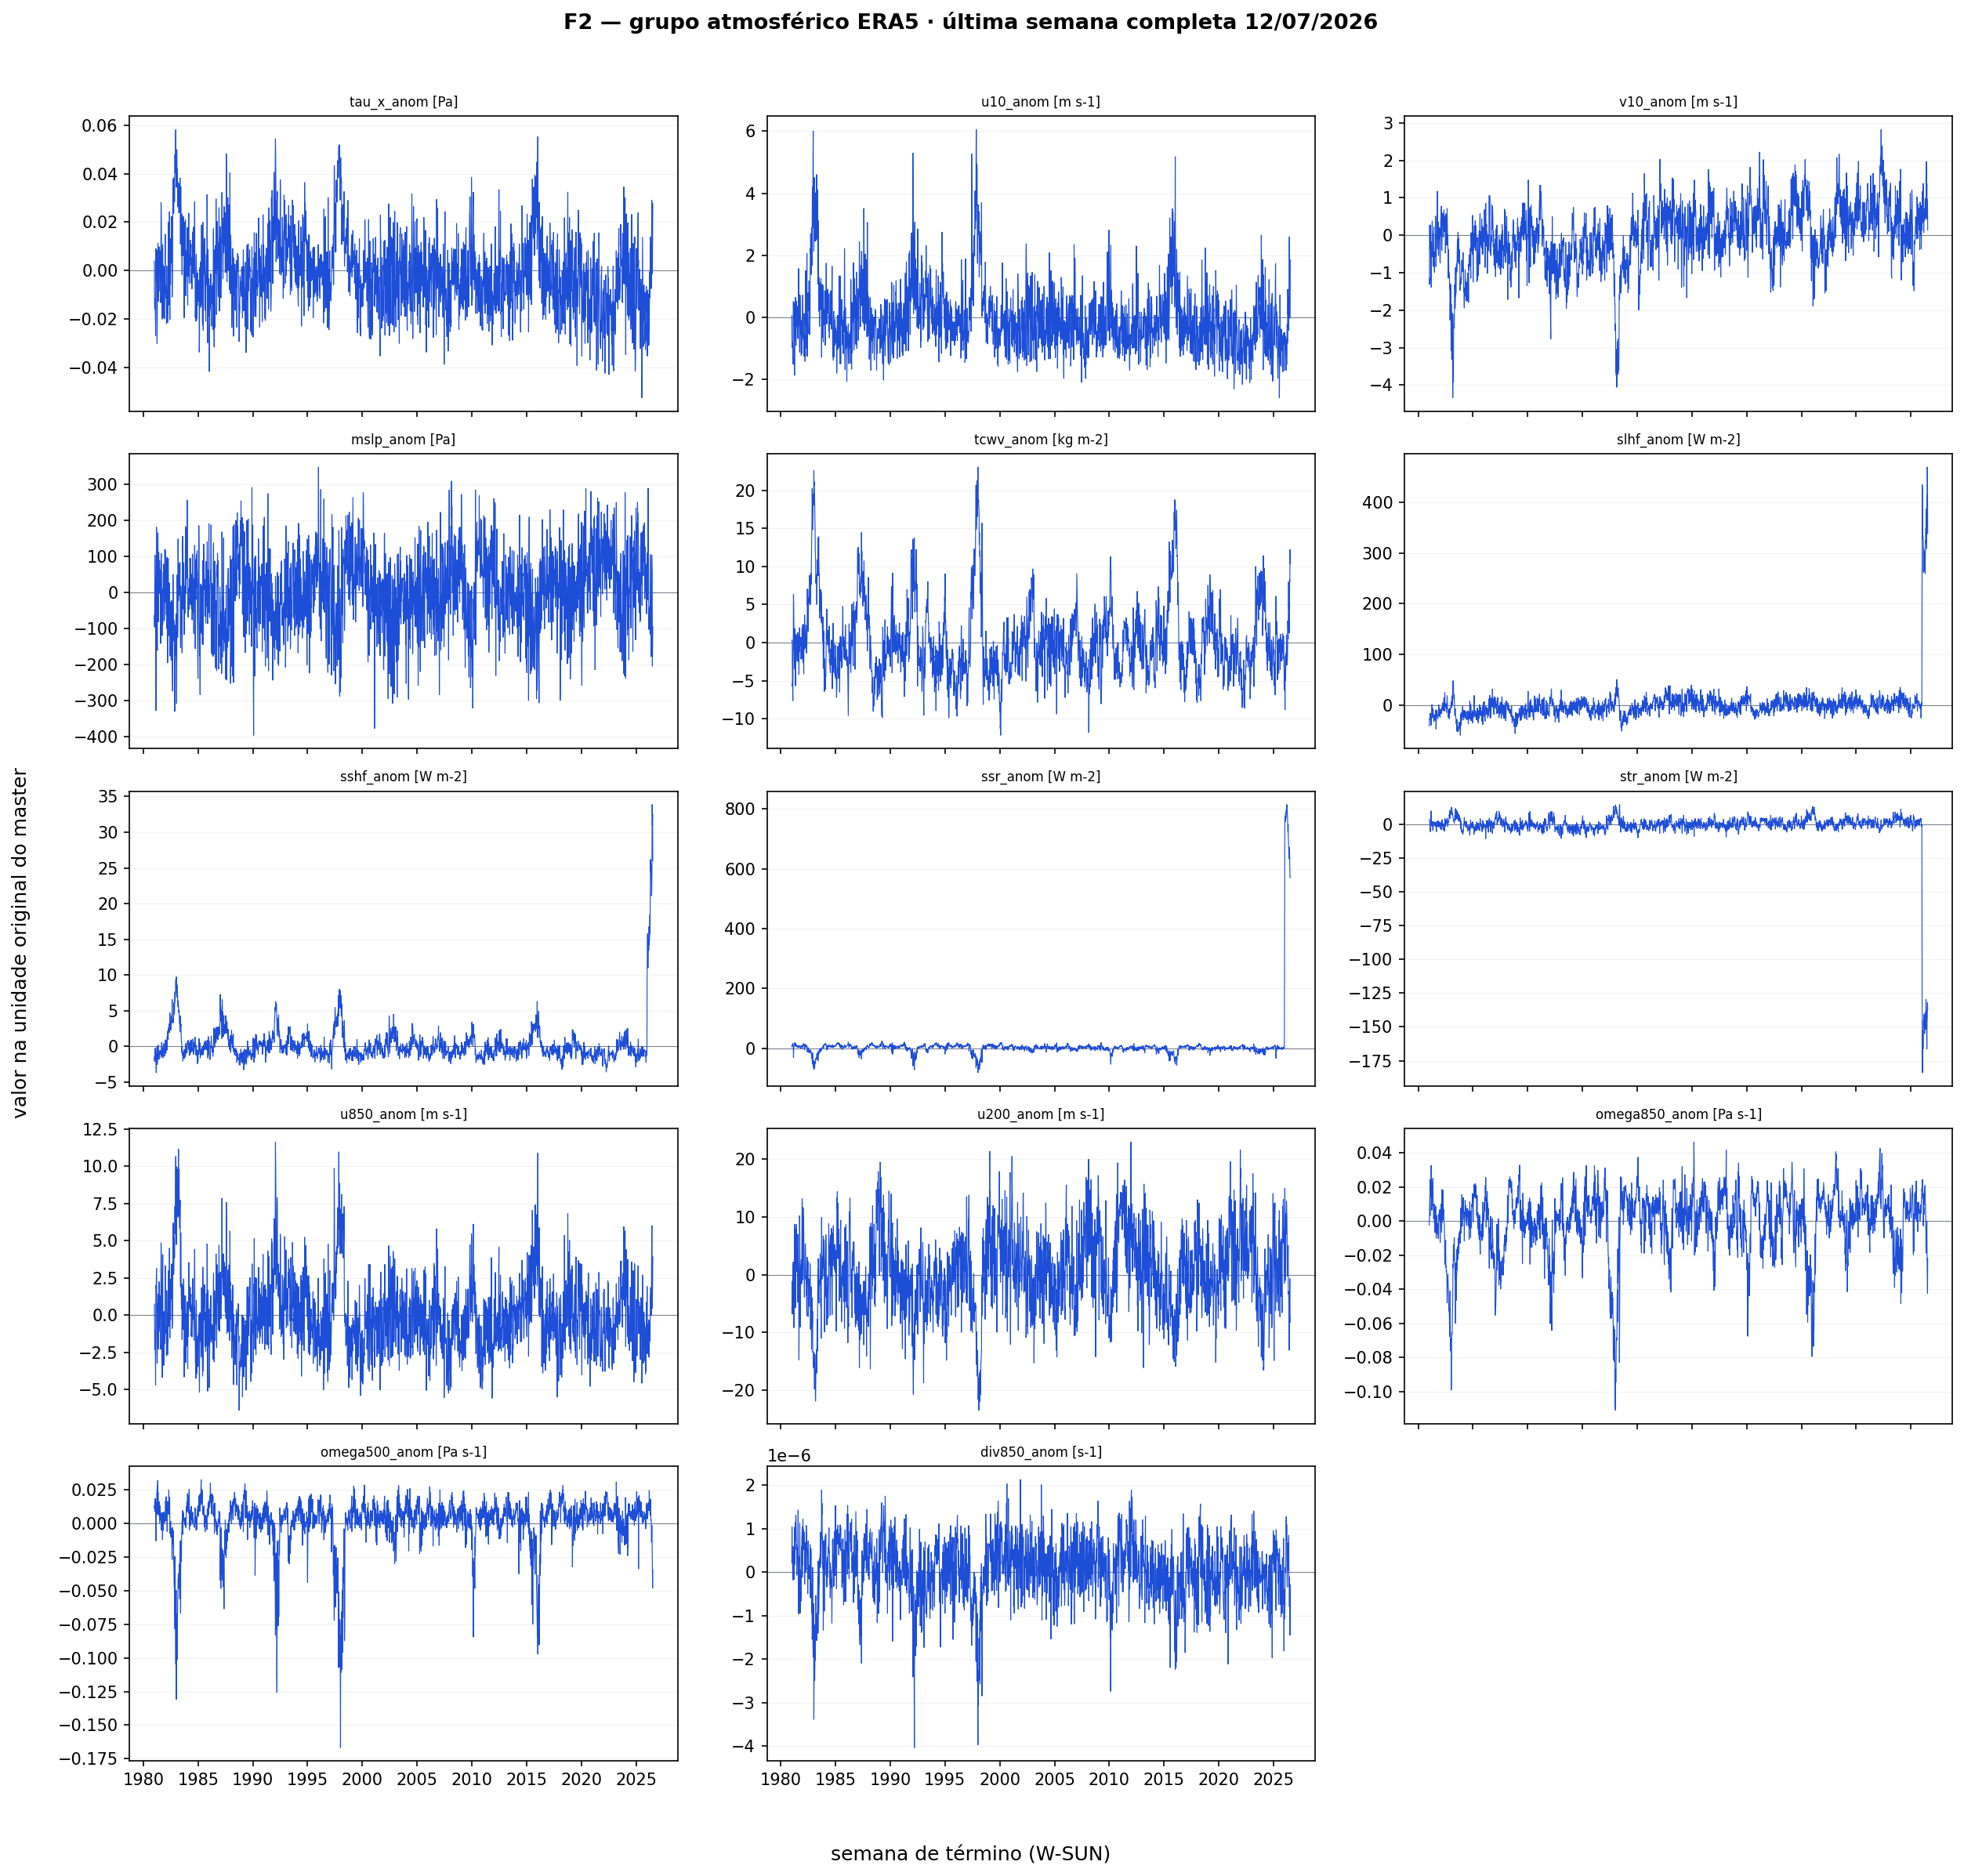

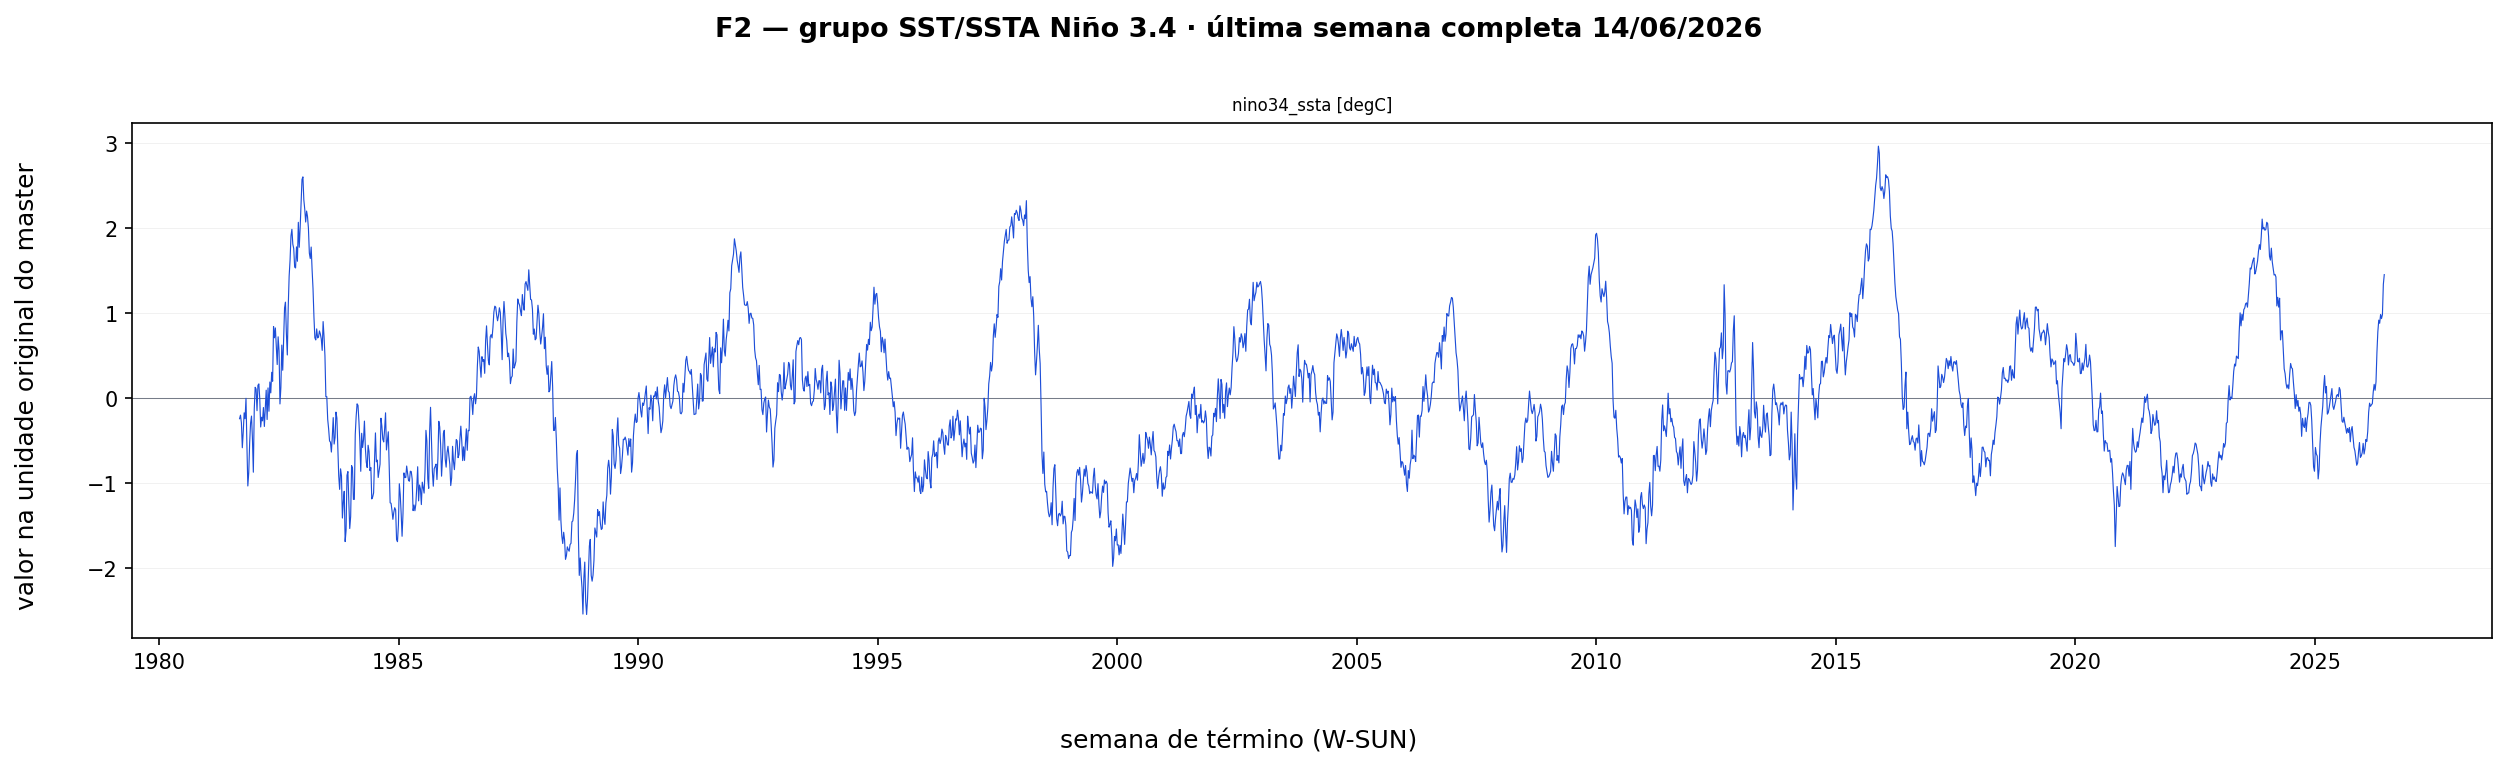

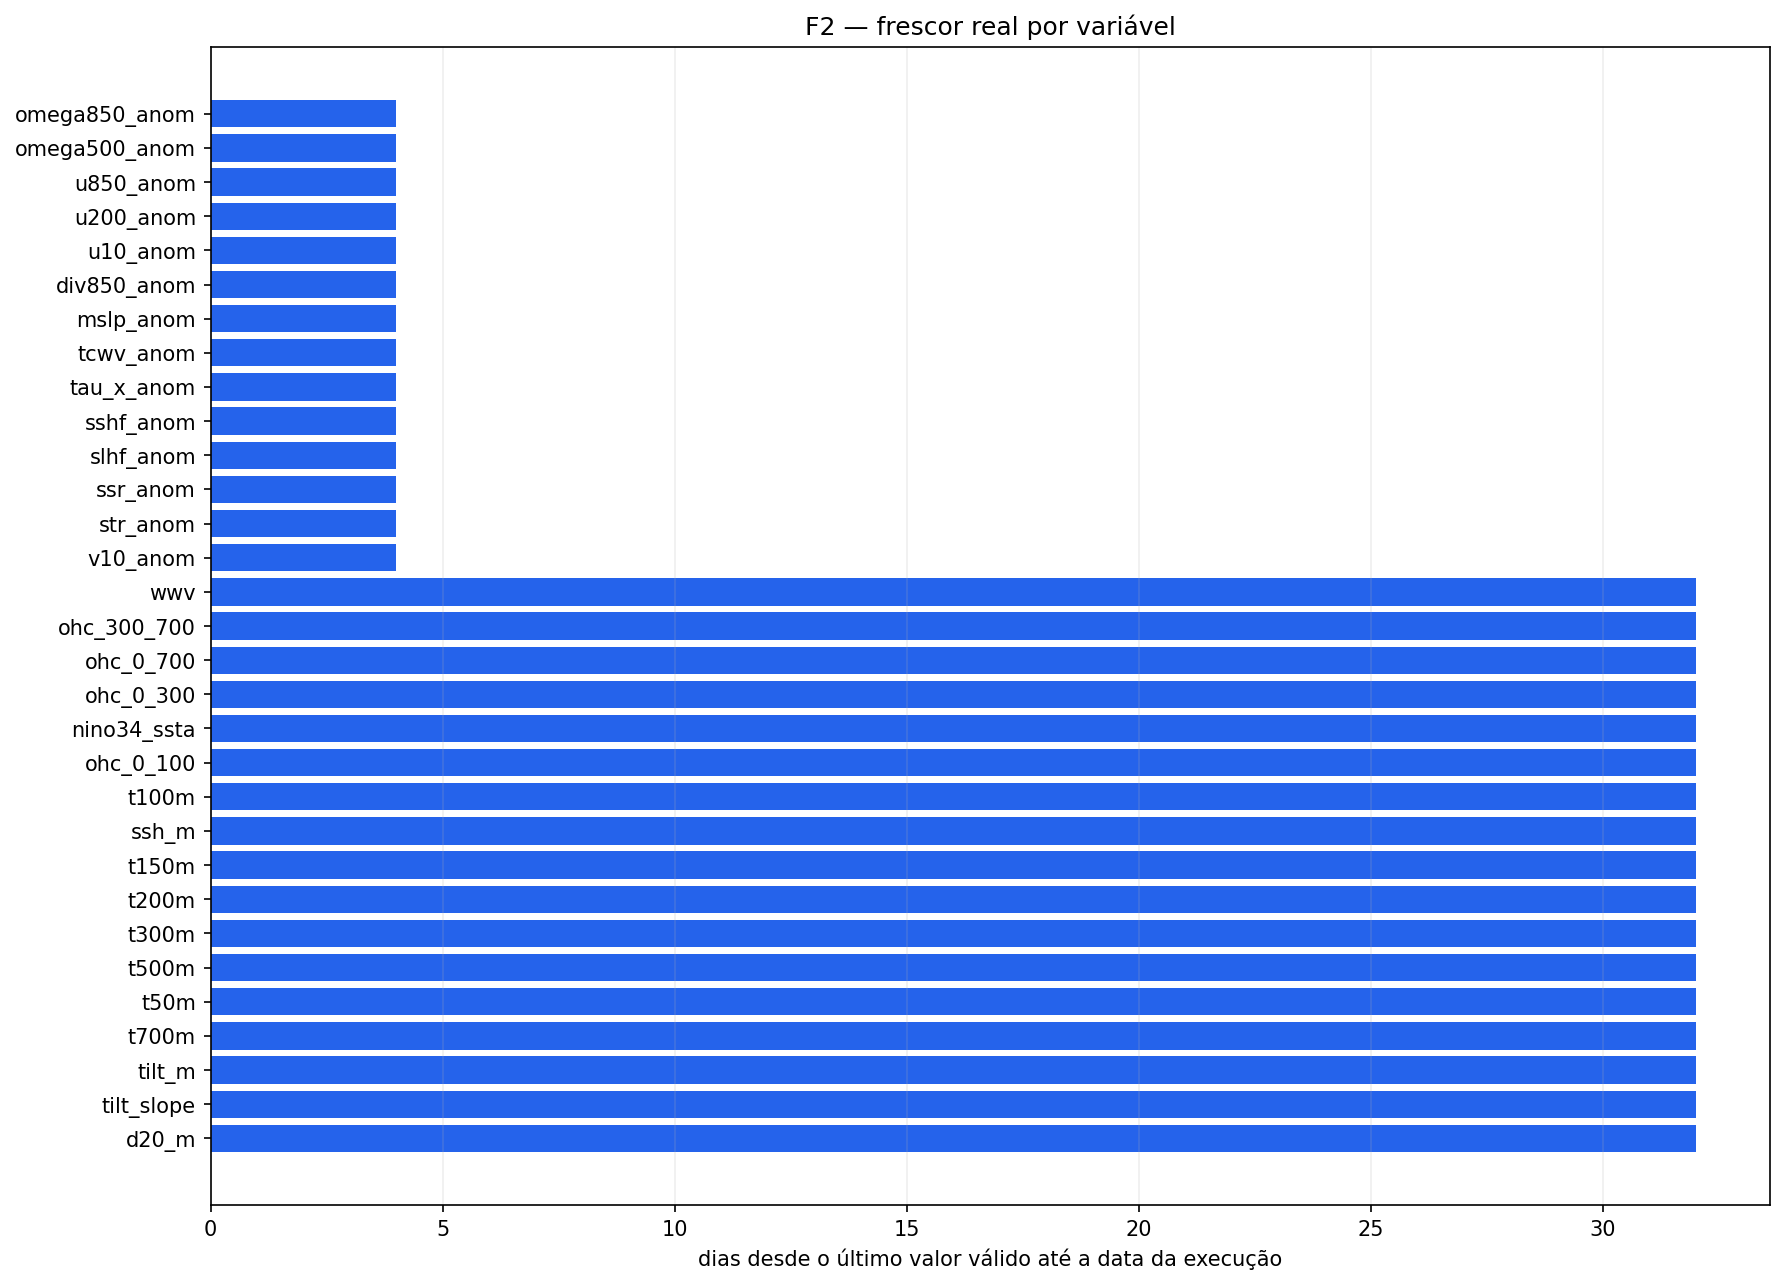

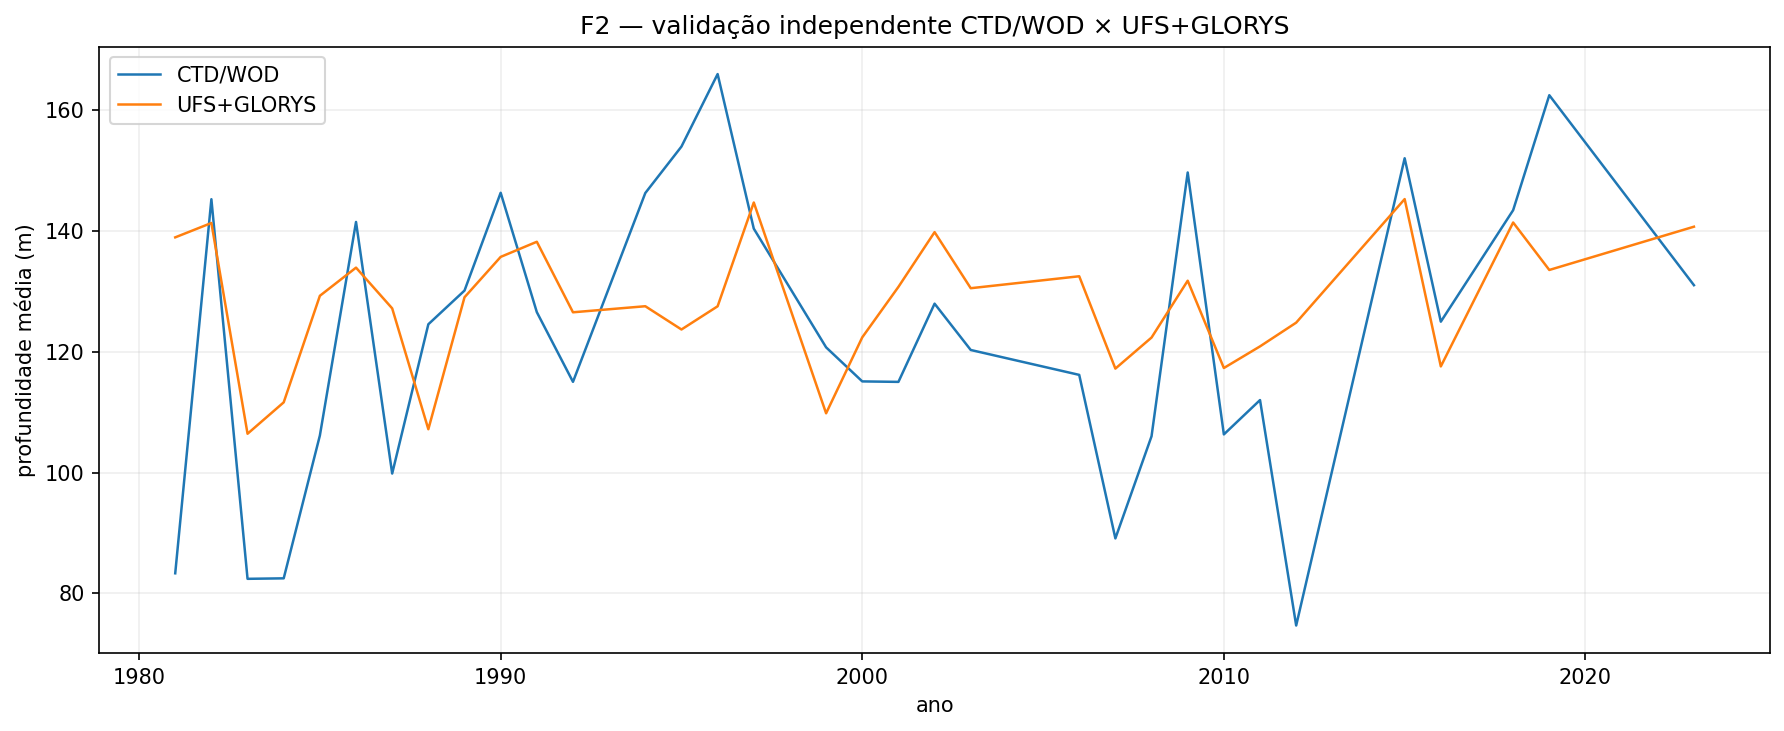

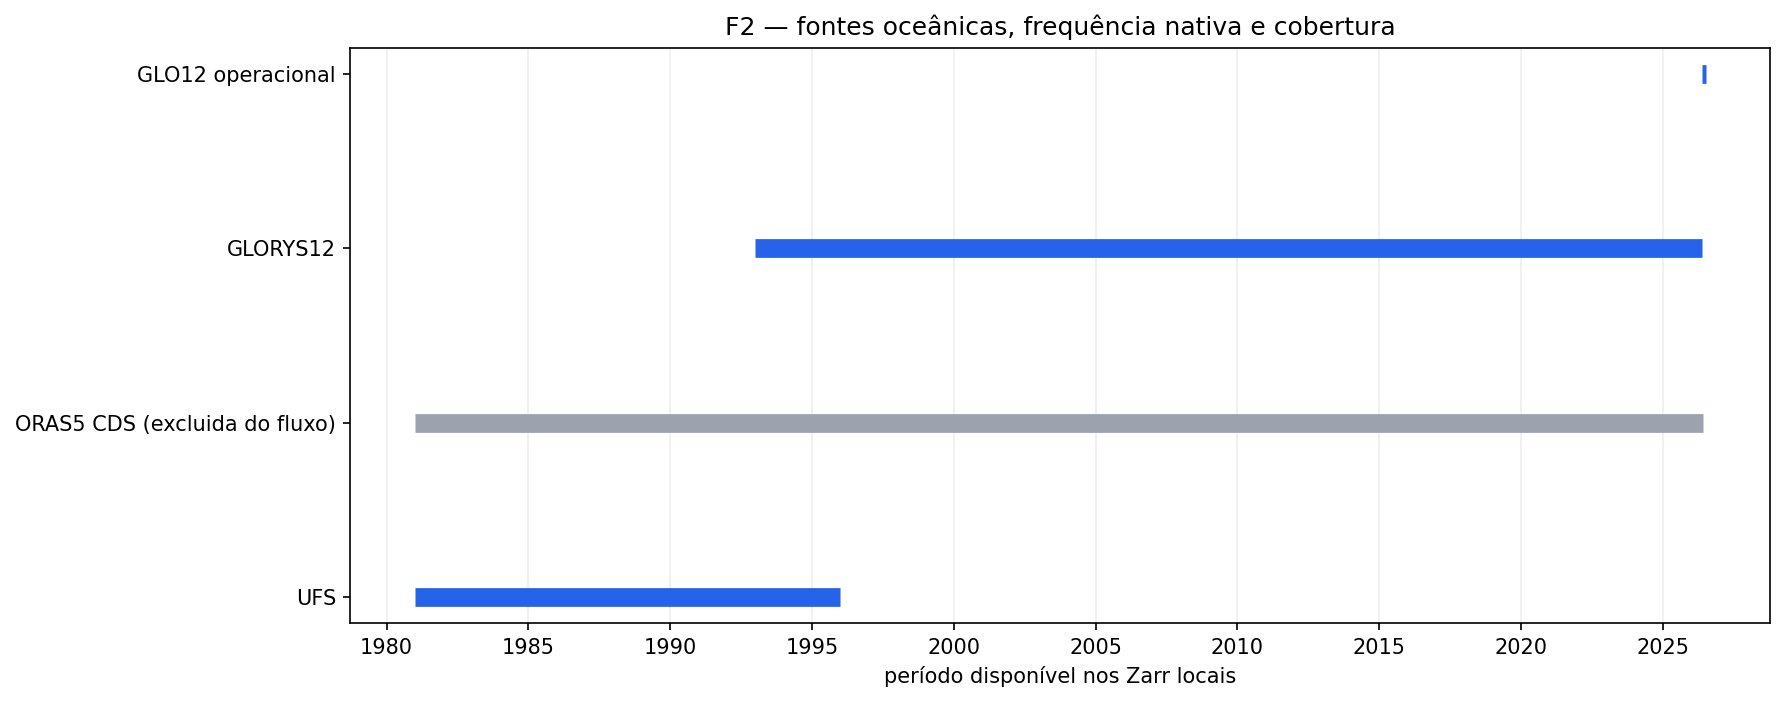

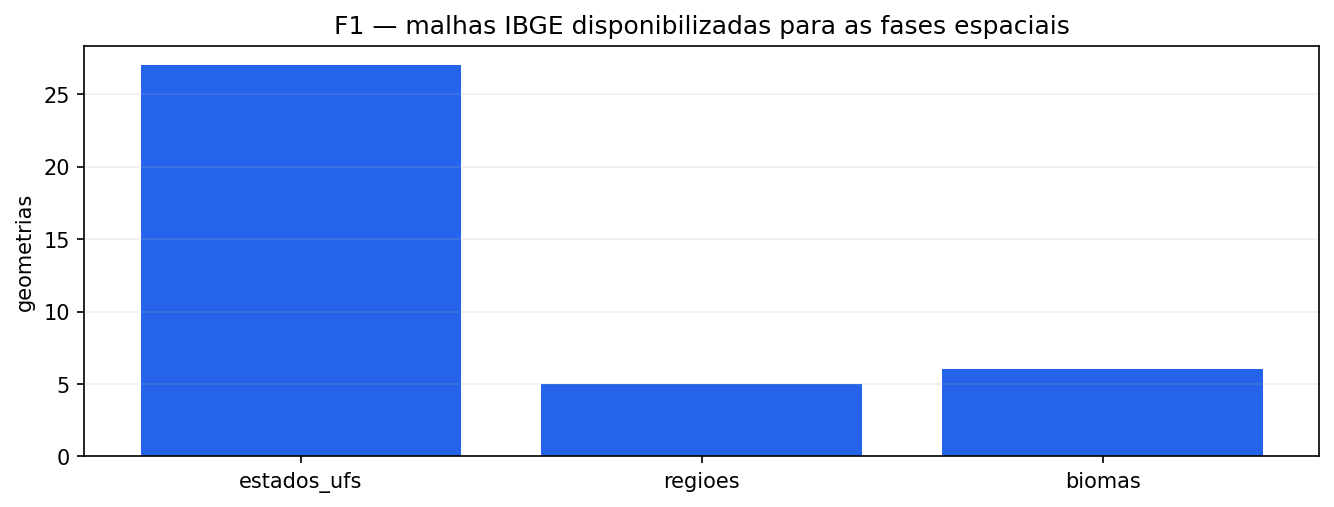

In [4]:
from IPython.display import Image, display

for artifact in result.artifacts.itertuples(index=False):
    display(Image(filename=str(artifact.figure_path)))

**CONCLUSÕES**

In [5]:
for item in result.takeaways:
    print(f'- {item}')
print('\nLimitações:')
for item in result.limitations:
    print(f'- {item}')

- O master semanal cobre 04/01/1981 a 12/07/2026.
- 31/31 variáveis atendem ao contrato para estatística semanal sem limpeza adicional.
- As entradas nativas são diárias (ERA5 parte de registros horários) e o produto da F2 é semanal; não há variável mensal independente nesta fase.
- A reconstituição da F2 usa exclusivamente períodos semanais com fechamento no domingo (W-SUN); datas diárias são apenas insumos da agregação.
- A última semana comum às 31 variáveis da base é 14/06/2026; a tabela de atualização preserva também a última semana individual de cada variável.
- A relação completa é publicada por variável, família e fonte; os agrupamentos servem apenas para organizar os gráficos e não substituem a auditoria integral da base.
- A maior data válida observada no audit é 12/07/2026; o eixo semanal sozinho não comprova atualização das fontes.
- O notebook publica a validação CTD/WOD e, quando disponível, a auditoria IBGE produzida pela F1.
- UFS+GLORYS fornece temperatura, salinidade 

**REFERÊNCIAS BIBLIOGRÁFICAS**

1. NINO-BRASIL. Documentação metodológica, contrato de dados e diretrizes da fase no repositório do projeto.